We develop a conditional Real NVP normalizing flow and train it on DNA atomic coordinates obtained from AMBER-based molecular dynamics simulations. The notebook was initially designed for Google Colab, therefore some dependency installation and runtime configuration steps are Colab-oriented and should be adjusted for non-Colab environments.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/'Colab Notebooks'/DNA_Final1

Mounted at /content/gdrive
/content/gdrive/MyDrive/Colab Notebooks/DNA_Final1


In [ ]:
!pip install netCDF4
!pip install parmed
!pip install openmm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 149.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 96.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 125.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for parmed: filename=ParmEd-4.3.0-cp312-cp312-linux_x86_64.whl size=19471508 sha256=7de37d6f100590bdda5fd4d8fd99717d56152657baa78a5c2714aa8983feb17d
  Stored in directory: /root/.cache/pip/wheels/a3/c6/57/3ff4e09a91685738568d531ee739797913dd13b3553e202234
Successfully built parmed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 116.9 MB/s eta 0:00:00


In [ ]:
import os
import re
import tqdm
import json
import time
import netCDF4
import numpy as np
import parmed as pmd
from tqdm import tqdm

import math
import pickle
import argparse
from sys import exit
from sklearn import datasets
import matplotlib.pyplot as plt

import openmm
from openmm import app, openmm
from openmm import unit, LangevinIntegrator
from openmm.app import AmberPrmtopFile, Simulation

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torch.nn.functional as F
import torch.nn.functional as functional
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float32)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


The DNA coordinates and simulation box information were generated with AMBER and are already pre-processed. The processed dataset is stored in all_traj_DNAonly.npz.

In [ ]:
data = np.load("all_traj_DNAonly.npz")

coords = data["coords"]
boxes  = data["boxes"]

print("coords shape:", coords.shape)
print("boxes shape :", boxes.shape)

coords shape: (8050, 1894, 3)
boxes shape : (8050, 3)


Once the trajectory data are loaded, we calculate the DNA extension for every frame using the coordinate list (e.g., an end-to-end measure derived from selected atoms). These per-frame extension values are then used as the condition for the conditional Real NVP during training.

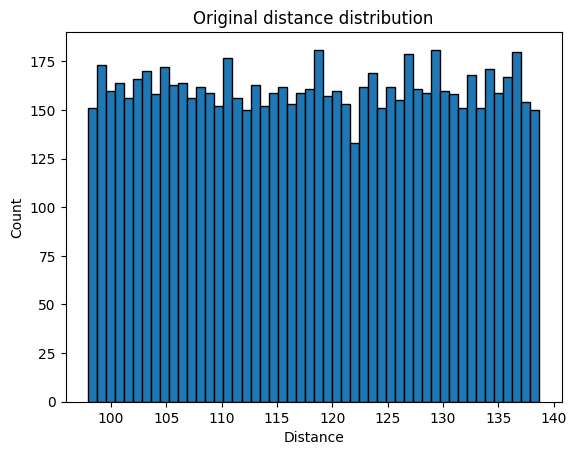

In [ ]:
p1, p2, p3, p4 = 30, 943, 946, 1871

def middlePoint(one, two):
    return (one + two) / 2.0

def dist(one, two):
    return math.sqrt(np.sum((one - two)**2))

def compute_distances(trajectories, p1, p2, p3, p4):
    distances = []
    for coords in trajectories:
        leftEnd  = middlePoint(coords[p1], coords[p4])
        rightEnd = middlePoint(coords[p2], coords[p3])
        distances.append(dist(leftEnd, rightEnd))
    return torch.tensor(distances, dtype=torch.float32).unsqueeze(1)

distances_orig = compute_distances(coords, p1, p2, p3, p4)

plt.hist(distances_orig.numpy(), bins=50, edgecolor='black')
plt.title("Original distance distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

Final pre-processing consists of:

*   Flattening: each coordinate frame is reshaped into a single vector size D.
*   Normalization (inputs): we compute the per-dimension mean and standard
deviation across the full dataset and standardize the flattened coordinates.
*   Normalization (condition): we likewise standardize the extension length values, which will be used as the Real NVP conditioning input.

The resulting tensors train_x (normalized flattened coordinates) and train_c (normalized conditions) are then used for model training.

In [ ]:
coords_np = coords.astype(np.float32)
coords_flat = coords_np.reshape(8050, -1)
coords_flat = torch.from_numpy(coords_flat)
D = coords_flat.shape[1]
print("Flattened dimension D:", D)

Flattened dimension D: 5682


In [ ]:
x_train_full = coords_flat
x_mean = x_train_full.mean(dim=0, keepdim=True)
x_std  = x_train_full.std(dim=0, keepdim=True) + 1e-6
x_all_norm = (coords_flat - x_mean) / x_std

In [ ]:
c_all = distances_orig
c_train_full = c_all
c_mean = c_train_full.mean(dim=0, keepdim=True)
c_std  = c_train_full.std(dim=0, keepdim=True) + 1e-6
c_all_norm = (c_all - c_mean) / c_std

In [ ]:
train_x = x_all_norm
train_c = c_all_norm

print("train_x:", train_x.shape, "train_c:", train_c.shape)

train_x: torch.Size([8050, 5682]) train_c: torch.Size([8050, 1])


We build the data loader and set the batch size to 16.

In [ ]:
batch_size = 16

train_ds = TensorDataset(train_x, train_c)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)

We build CondNet as a way to embed the distance into a more complex entry for the condition since the length is just a scalar, and the model would need a more complex interpretation of that length.

In [ ]:
class CondNet(nn.Module):
    def __init__(self, cond_dim=1, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim),
            nn.ReLU(),
        )

    def forward(self, c):
        return self.net(c)


Next, we define the Real NVP affine coupling layer. A binary mask decides which part of the input stays unchanged. The unchanged part (plus the condition embedding) is fed into a small neural network to predict scale and shift values, which are applied to the remaining dimensions. We also compute the log-determinant needed for training, and we provide an inverse() method to map back to the original space.

In [ ]:
class CouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim, cond_emb_dim, mask):
        super().__init__()
        self.dim = dim
        self.register_buffer("mask", mask.float())

        input_dim = dim + cond_emb_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim * 2),
        )

    def forward(self, x, cond_emb):

        m = self.mask.to(x.device)
        x_masked = x * m

        inp = torch.cat([x_masked, cond_emb], dim=1)
        s, t = self.net(inp).chunk(2, dim=1)

        s = torch.tanh(s) * 1.5
        scale = torch.exp(s)

        y = x_masked + (1 - m) * (x * scale + t)
        logdet = ((1 - m) * s).sum(dim=1)

        return y, logdet

    def inverse(self, y, cond_emb):

        m = self.mask.to(y.device)
        y_masked = y * m

        inp = torch.cat([y_masked, cond_emb], dim=1)
        s, t = self.net(inp).chunk(2, dim=1)

        s = torch.tanh(s) * 1.5
        scale = torch.exp(s)

        x = y_masked + (1 - m) * ((y - t) / scale)
        logdet = -((1 - m) * s).sum(dim=1)

        return x, logdet

We now build the conditional Real NVP model. In addition to the coordinates
x, the model takes the end-to-end distance c as an extra input. We first pass
c through a small network (CondNet) to get a condition embedding. That embedding is then provided to every affine coupling layer, so the flow can learn how the coordinate distribution changes as the DNA extension changes.

The Real NVP is made of several coupling layers with alternating masks, and we implement both the forward transform (to latent space z and total log-determinant) and the inverse transform (sampling back from z to coordinates).

In [ ]:
class RealNVP(nn.Module):
    def __init__(self, dim, n_layers=6, hidden_dim=512,
                 cond_dim=1, cond_emb_dim=32):
        super().__init__()
        self.dim = dim
        self.cond_net = CondNet(cond_dim=cond_dim, embed_dim=cond_emb_dim)

        masks = []
        for i in range(n_layers):
            mask = torch.zeros(dim)
            mask[i % 2 :: 2] = 1.0
            masks.append(mask)

        self.layers = nn.ModuleList([
            CouplingLayer(dim, hidden_dim, cond_emb_dim, masks[i])
            for i in range(n_layers)
        ])

    def forward(self, x, c):
        cond_emb = self.cond_net(c)
        logdet_sum = torch.zeros(x.shape[0], device=x.device)

        z = x
        for layer in self.layers:
            z, logdet = layer(z, cond_emb)
            logdet_sum += logdet
        return z, logdet_sum

    def inverse(self, z, c):
        cond_emb = self.cond_net(c)
        logdet_sum = torch.zeros(z.shape[0], device=z.device)
        x = z
        for layer in reversed(self.layers):
            x, logdet = layer.inverse(x, cond_emb)
            logdet_sum += logdet

        return x, logdet_sum


We initialise the Real NVP model and the Adam optimiser.

In [ ]:
model = RealNVP(dim=D, n_layers=6, hidden_dim=512,
                cond_dim=1, cond_emb_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

We now define the negative log-likelihood (NLL) loss for the flow and train the model. For each batch, we map the coordinates x (conditioned on the extension c) to latent variables z, assume a standard normal prior over z, and use the log-determinant from the coupling layers to compute the data log-likelihood. We then minimize the average NLL using backpropagation and an optimizer for 200 epochs, recording the training loss each epoch.

In [ ]:
def flow_nll(model, x, c):
    z, logdet = model(x, c)
    log_pz = -0.5 * torch.sum(z**2, dim=1)
    log_px = log_pz + logdet
    nll = -log_px.mean()
    return nll

n_epochs = 200
train_losses = []
for epoch in range(1, n_epochs+1):
    model.train()
    train_loss = 0.0
    for x_batch, c_batch in train_loader:
        x_batch = x_batch.to(device)
        c_batch = c_batch.to(device)

        optimizer.zero_grad()
        loss = flow_nll(model, x_batch, c_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    print(f"Epoch {epoch:03d} | train NLL: {train_loss:.4f}")

Epoch 001 | train NLL: -1800.5093
Epoch 002 | train NLL: -4620.1934
Epoch 003 | train NLL: -5615.6345
Epoch 004 | train NLL: -6268.9496
Epoch 005 | train NLL: -6726.5026
Epoch 006 | train NLL: -7135.3231
Epoch 007 | train NLL: -7449.0553
Epoch 008 | train NLL: -7737.7180
Epoch 009 | train NLL: -7971.0402
Epoch 010 | train NLL: -8184.9989
Epoch 011 | train NLL: -8390.2717
Epoch 012 | train NLL: -8558.5043
Epoch 013 | train NLL: -8710.7344
Epoch 014 | train NLL: -8863.9559
Epoch 015 | train NLL: -9011.8670
Epoch 016 | train NLL: -9132.7155
Epoch 017 | train NLL: -9245.9270
Epoch 018 | train NLL: -9353.8249
Epoch 019 | train NLL: -9488.6805
Epoch 020 | train NLL: -9589.5895
Epoch 021 | train NLL: -9673.1352
Epoch 022 | train NLL: -9765.6054
Epoch 023 | train NLL: -9856.9858
Epoch 024 | train NLL: -9937.3568
Epoch 025 | train NLL: -10028.2612
Epoch 026 | train NLL: -10089.8546
Epoch 027 | train NLL: -10184.4319
Epoch 028 | train NLL: -10228.1049
Epoch 029 | train NLL: -10298.6061
Epoch 030

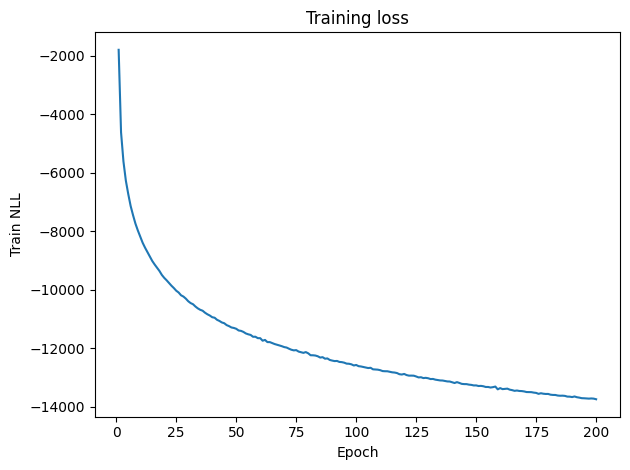

In [ ]:
plt.figure()
plt.plot(range(1, n_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train NLL")
plt.title("Training loss")
plt.tight_layout()
plt.show()

We put the model in evaluation mode and define a function to sample new structures. It draws random latent vectors z, runs the flow inverse with a chosen (normalized) condition c_norm, then un-normalizes and reshapes the output back into (n_samples, 1894, 3) coordinates.

In [ ]:
model.eval()

def sample_structs(c_norm, n_samples=1):

    with torch.no_grad():
        z = torch.randn(n_samples, D, device=device)
        c = torch.full((n_samples, 1), float(c_norm), device=device)
        x_norm, _ = model.inverse(z, c)


        x = x_norm.cpu() * x_std + x_mean
        x = x.reshape(n_samples, 1894, 3)
    return x

This function uses OpenMM to energy-minimize a set of coordinates.

It loads the AMBER topology/restart files, sets the input coordinates as the starting structure, runs minimization, then returns the minimized coordinates plus the initial/final energies.

In [ ]:
def minimize_coords_with_openmm(
    coords,
    top_file,
    rst_file,
    n_atoms_keep=1894,
    use_gb=True,
    max_iterations=500,
    tolerance=None,
    platform_name=None,  # "CUDA", "OpenCL", "CPU"
):


    coords = np.asarray(coords)
    if tolerance is None:
        tolerance = 10.0 * unit.kilojoules_per_mole / unit.nanometer


    structure = pmd.load_file(top_file, rst_file)[:n_atoms_keep]
    system = structure.createSystem(
        nonbondedMethod=app.CutoffNonPeriodic,
        nonbondedCutoff=1.2 * unit.nanometer,
        constraints=None,
        implicitSolvent=app.OBC2 if use_gb else None,
    )


    topology = structure.topology
    integrator = openmm.VerletIntegrator(1.0 * unit.femtoseconds)



    if platform_name is not None:
        platform = openmm.Platform.getPlatformByName(platform_name)
        simulation = app.Simulation(topology, system, integrator, platform)
    else:
        simulation = app.Simulation(topology, system, integrator)
        platform = simulation.context.getPlatform()


    coords_nm = coords[0] * 0.1
    simulation.context.setPositions(coords_nm)
    state0 = simulation.context.getState(getEnergy=True)
    E0 = state0.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)


    t0 = time.perf_counter()
    simulation.minimizeEnergy(tolerance=tolerance, maxIterations=max_iterations)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    print(f"Minimization finished in {elapsed:.2f} s")


    state = simulation.context.getState(getPositions=True, getEnergy=True)
    E_final = state.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)


    energies = {}
    for i, f in enumerate(system.getForces()):
        st_i = simulation.context.getState(getEnergy=True, groups=1 << i)
        energies[f.__class__.__name__] = st_i.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)


    labels = {
        "HarmonicBondForce": "bond",
        "HarmonicAngleForce": "angle",
        "PeriodicTorsionForce": "torsion",
        "RBTorsionForce": "torsion_rb",
        "NonbondedForce": "nonbonded",
    }
    energies_all = {labels.get(k, k): v for k, v in energies.items()}

    print(f"Final potential energy: {E_final:.2f} kcal/mol")

    positions_nm = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    coords_min_angs = np.array(positions_nm) * 10.0
    coords_min_angs = coords_min_angs[np.newaxis, ...]

    return coords_min_angs, E0, E_final, elapsed, energies_all

This function saves a generated structure to a PDB file.

It takes the generated coordinates, optionally relaxes/minimizes them with OpenMM, then loads the AMBER topology/restart, trims to the DNA atoms, replaces the coordinates, and writes the result to out_file.

In [ ]:
def save_generated_pdb(
    coords,
    topology_file="topology1.prmtop",
    rst_file="stretch1.rst7",
    n_atoms_keep=1894,
    out_file="generated_sample.pdb",
    relax=False,
    use_gb=True,
    max_iterations=500,
    tolerance=None,
    platform_name=None,
):


    coords = np.asarray(coords)
    if relax:
        print("Running OpenMM minimization")
        coords_relaxed, E0, E_final, elapsed, _ = minimize_coords_with_openmm(
            coords=coords,
            top_file=topology_file,
            rst_file=rst_file,
            n_atoms_keep=n_atoms_keep,
            use_gb=use_gb,
            max_iterations=max_iterations,
            tolerance=tolerance,
            platform_name=platform_name,
        )
        coords_to_save = coords_relaxed

    else:
        coords_to_save = coords
        print("Skipping minimization; saving raw generated coordinates.")


    full = pmd.load_file(topology_file, rst_file)
    trimmed = full[:n_atoms_keep]
    trimmed.coordinates = coords_to_save[0]
    os.makedirs(os.path.dirname(out_file) or ".", exist_ok=True)
    trimmed.save(out_file, overwrite=True)


    return trimmed

Here we generate a new DNA sample from the trained flow at a chosen condition value (c_norm=2), select one of the generated structures, reshape it to the expected (1, 1894, 3) format, and then save it as a PDB file.
Before saving, we set relax=True so the structure is energy-minimized in OpenMM (with implicit solvent/GB) using the OpenCL platform.

In [ ]:
def distance_to_norm(d_raw):
    return float((d_raw - c_mean.item()) / c_std.item())

In [ ]:
c_norm = distance_to_norm(d_raw=100)
coords_gen = sample_structs(c_norm)

In [ ]:
pdb_struct = save_generated_pdb(
    coords=coords_gen,
    topology_file="topology1.prmtop",
    rst_file="stretch1.rst7",
    n_atoms_keep=1894,
    out_file="cond_seq_100_relaxed.pdb",
    relax=True,
    use_gb=True,
    max_iterations=500,
    platform_name="OpenCL",
)

Running OpenMM minimization
Minimization finished in 0.18 s
Final potential energy: -17637.10 kcal/mol


This block collects samples from 4 different conditional values.
For each chosen condition value (c_norm), it:

*  generates n_samples structures with sample_structs
*  minimizes each structure in OpenMM
*  collects the energy terms from each minimization
*  saves the list of energies to a JSON file

Since, it takes a long time to proces, run it only when you need a lot of samples.

This code is cricuial in generating the required input files for energy/Energy_Eval.ipynb.

In [ ]:
"""
PARAM_SETS = [
    (-1.5, "energies_all_list_low-15.json"),
    (-0.5, "energies_all_list_low-05.json"),
    ( 0.5, "energies_all_list05.json"),
    ( 1.5, "energies_all_list15.json"),
]

def run_batch(c_norm: float, out_path: str, n_samples: int = 500, log_every: int = 25):
    coords_gen = sample_structs(c_norm=c_norm, n_samples=n_samples)
    energies_list = []

    t0 = time.perf_counter()
    for i in range(n_samples):
        t_i0 = time.perf_counter()

        i_coords = coords_gen[i]
        _, _, _, _, energies_all = minimize_coords_with_openmm(
            coords=i_coords[np.newaxis, ...],
            top_file="topology1.prmtop",
            rst_file="stretch1.rst7",
            n_atoms_keep=1894,
            use_gb=True,
            max_iterations=500,
            platform_name="OpenCL",
        )
        energies_list.append(energies_all)

        # timing / progress
        if (i + 1) % log_every == 0 or (i + 1) == n_samples:
            elapsed = time.perf_counter() - t0
            avg = elapsed / (i + 1)
            remaining = avg * (n_samples - (i + 1))
            last = time.perf_counter() - t_i0

            print(
                f"[c_norm={c_norm:+.1f}] {i+1:>4}/{n_samples} | "
                f"last={last:6.2f}s avg={avg:6.2f}s | "
                f"elapsed={elapsed/60:6.2f}m ETA={remaining/60:6.2f}m"
            )

    # write output
    with open(out_path, "w") as f:
        json.dump(energies_list, f, indent=2)

    total = time.perf_counter() - t0
    print(f"Wrote {len(energies_list)} samples to {out_path} "
          f"(total {total/60:.2f}m, avg {total/len(energies_list):.2f}s/sample)")

    return energies_list


for c_norm, out_path in PARAM_SETS:
    run_batch(c_norm=c_norm, out_path=out_path, n_samples=500, log_every=25)
"""

'\nPARAM_SETS = [\n    (-1.5, "energies_all_list_low-15.json"),\n    (-0.5, "energies_all_list_low-05.json"),\n    ( 0.5, "energies_all_list05.json"),\n    ( 1.5, "energies_all_list15.json"),\n]\n\ndef run_batch(c_norm: float, out_path: str, n_samples: int = 500, log_every: int = 25):\n    coords_gen = sample_structs(c_norm=c_norm, n_samples=n_samples)\n    energies_list = []\n\n    t0 = time.perf_counter()\n    for i in range(n_samples):\n        t_i0 = time.perf_counter()\n\n        i_coords = coords_gen[i]\n        _, _, _, _, energies_all = minimize_coords_with_openmm(\n            coords=i_coords[np.newaxis, ...],\n            top_file="topology1.prmtop",\n            rst_file="stretch1.rst7",\n            n_atoms_keep=1894,\n            use_gb=True,\n            max_iterations=500,\n            platform_name="OpenCL",\n        )\n        energies_list.append(energies_all)\n\n        # timing / progress\n        if (i + 1) % log_every == 0 or (i + 1) == n_samples:\n            ela